<a href="https://colab.research.google.com/github/tanjiro040/tanjiro040/blob/main/data_mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

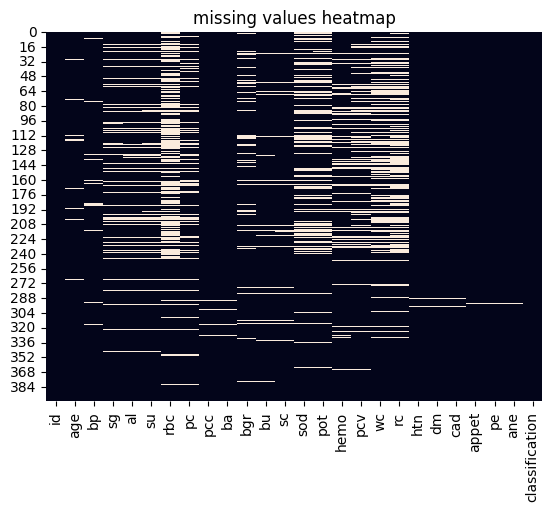

missing values handled
      id   age    bp     sg   al   su     rbc        pc         pcc  \
0      0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent   
1      1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent   
2      2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent   
3      3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present   
4      4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent   
..   ...   ...   ...    ...  ...  ...     ...       ...         ...   
395  395  55.0  80.0  1.020  0.0  0.0  normal    normal  notpresent   
396  396  42.0  70.0  1.025  0.0  0.0  normal    normal  notpresent   
397  397  12.0  80.0  1.020  0.0  0.0  normal    normal  notpresent   
398  398  17.0  60.0  1.025  0.0  0.0  normal    normal  notpresent   
399  399  58.0  80.0  1.025  0.0  0.0  normal    normal  notpresent   

             ba  ...  pcv    wc   rc  htn   dm  cad appet   pe  ane  \
0    notpresent  ...   44  7800  5.2  yes  yes   no  

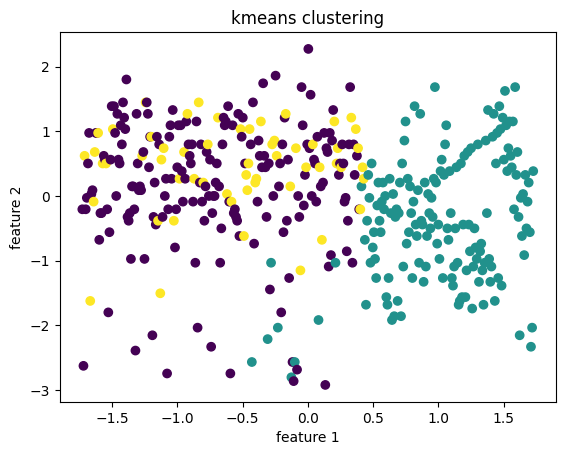

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#loading dataset
df = pd.read_csv('kidney_disease.csv')

#Exploratory data analysis
print(df.info())
print(df.describe())
sns.heatmap( df.isnull() , cbar = False )
plt.title("missing values heatmap")
plt.show()

#handle missing values
df.fillna(df.select_dtypes(include=['number']).mean(), inplace=True)
print("missing values handled")
print(df)

#descritization
df['age_bins'] = pd.cut(df['age'] ,bins = [0,20,40,60,80],labels = ['0-20','21-40','41-60','61-80'])
print(df['age_bins'].head())


#Q2 - k means algorithm for clustering dataset
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#prepare data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df.select_dtypes(include = np.number))
#apply k means
kmeans = KMeans(n_clusters = 3,random_state=42)
df['cluster'] = kmeans.fit_predict(data_scaled)
#visualize clusters
plt.scatter(data_scaled[:,0],data_scaled[:,1],c = df['cluster'])
plt.title("kmeans clustering")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.show()